# 1. Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

# Affiche toutes les lignes
pd.set_option('display.max_rows', None)

# Affiche toutes les colonnes
pd.set_option('display.max_columns', None)
# Choisis le nombre de caractère par colonnes
pd.set_option('display.max_colwidth', 50)

In [2]:
from nltk import tokenize

# 2. Fonctions de visualisation

In [3]:
def first_overview(df, name):
    print(f'Shape of {name} dataset : {df.shape}\n')
    print(f'Number of duplicate : {df.duplicated().sum()}\n')
    if df.shape[1] < 20:
        print(f'Variable types : \n{df.dtypes}\n')
    else:
        print(f'Variable types : \n{df.dtypes.value_counts()}\n')
    display(df.head(2))
    display(df.describe().T)
    try:
        display(df.describe(include=('object', 'str')).T)
    except:
        pass
    return 

In [4]:
def missing_val_overview(df, all_col=True):

    if all_col==True:
        info_col = df.columns
    else:
        info_col = df.columns[df.isna().any()]

    missing_table = pd.DataFrame({'Number': df[info_col].isna().sum(), 'Ratio': np.round(df[info_col].isna().sum()/df[info_col].shape[0]*100, 2)})
    missing_table = missing_table.sort_values(by='Ratio',ascending=False)
    print(f'Missing values : \n{missing_table}\n')
    
    plt.figure(figsize=(20, 5))
    sns.heatmap(df[info_col].isna(), cbar=False)
    plt.title('NaN values visualisation')
    plt.show()

In [5]:
def proportion_visualisation(df, num_col):
    # Number of columns and rows
    n = len(num_col)
    cols = 4
    rows = math.ceil(n / cols)
    # Main fig - size
    fig = plt.figure(figsize=(6*cols, 5*rows))
    # Sub fig - number
    outer = fig.add_gridspec(rows, cols)
    #
    for i, col in enumerate(num_col):
        # Fig location
        c = i % cols
        r = i // cols
        # Sub fig - parameters
        inner = outer[r, c].subgridspec(2, 1, height_ratios=[0.85, 0.15])
        # Add axis
        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1])
        # first graph
        sns.histplot(df[col], ax=ax1)
        ax1.set_xlabel('')
        ax1.set_ylabel('Count')
        ax1.set_title(f'| {col} | - Histplot and Boxplot')
        # Second graph
        sns.boxplot(x=df[col], ax=ax2)
        ax2.set_xlabel('')
        ax2.set_ylabel('')
    #
    plt.tight_layout()
    plt.show()

In [6]:
def regplot_visualisation(df, num_col, target):
    
    # Number of columns and rows
    n = len(num_col)
    cols = 4
    rows = math.ceil(n / cols)

    # Main fig - size
    fig = plt.figure(figsize=(6*cols, 5*rows))

    # Sub fig - number
    outer = fig.add_gridspec(rows, cols)

    for i, col in enumerate(num_col):

        # Fig location
        c = i % cols
        r = i // cols

        # Sub fig - parameters
        inner = outer[r, c].subgridspec(2, 1, height_ratios=[0.85, 0.15])

        # Add axis
        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1])

        # First graph : regplot with target
        sns.regplot(data=df, x=col, y=target, ax=ax1, scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
        ax1.set_xlabel('')
        ax1.set_ylabel(target)
        ax1.set_title(f'| {col} | - Regplot with {target}')

        # Second graph : histogram
        sns.histplot(df[col], ax=ax2)
        ax2.set_xlabel(col)
        ax2.set_ylabel('')

    plt.tight_layout()
    plt.show()

# 3. Téléchargement du dataset

In [7]:
data_path = 'washington_ultimate.csv'

data_raw = pd.read_csv(data_path)

In [8]:
df = data_raw.copy()

# 4. Visualisation globale des données

### 4.a Dataset globale

In [9]:
first_overview(df, 'Washington real estate')

Shape of Washington real estate dataset : (12017, 15)

Number of duplicate : 0

Variable types : 
zip                   float64
type                      str
year_built            float64
listPrice             float64
lastSoldPrice         float64
list_to_sold_ratio    float64
sqft                  float64
price_per_sqft        float64
stories               float64
beds                  float64
baths                 float64
baths_full            float64
baths_full_calc       float64
garage                float64
sanitized_text            str
dtype: object



,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text
0,99156.0,single_family,1997.0,875054.0,875085.0,1.000,2710.0,322.91,1.0,3.0,3.0,2.0,2.0,3.0,"2, 700+ sq ft residence features 3 beds, 2.5 b..."
1,99006.0,single_family,1900.0,349989.0,347902.0,0.994,1460.0,238.29,2.0,3.0,2.0,2.0,2.0,NaN,"this beautifully remodeled 3-bedroom, 2-bath h..."


,count,mean,std,min,25%,50%,75%,max
zip,12014.0,98470.878059,396.832853,98001.0000,98122.0000,98371.0,98665.0000,9.940300e+04
year_built,11157.0,1985.959129,32.268603,1875.0000,1967.0000,1992.0,2013.0000,2.026000e+03
listPrice,10325.0,701848.628184,550703.149523,1000.0000,405062.0000,569974.0,800081.0000,1.090007e+07
lastSoldPrice,12002.0,729124.509915,707800.246765,1000.0000,400028.7500,568006.0,824912.0000,1.575121e+07
list_to_sold_ratio,10310.0,0.991343,0.062016,0.0028,0.9783,1.0,1.0004,2.224900e+00
sqft,11145.0,2007.775684,1113.447253,120.0000,1340.0000,1810.0,2440.0000,2.968000e+04
price_per_sqft,11121.0,367.886257,189.541242,0.6500,251.3900,324.3,440.6600,1.988730e+03
stories,10506.0,1.561965,0.775282,0.0000,1.0000,2.0,2.0000,3.100000e+01
beds,11085.0,3.262517,1.112333,0.0000,3.0000,3.0,4.0000,1.800000e+01
baths,11533.0,2.363565,1.151564,0.0000,2.0000,2.0,3.0000,2.000000e+01


,count,unique,top,freq
type,12017,9,single_family,8840
sanitized_text,10298,10133,the foyer is open to spacious great room with ...,8


### 4.b Valeurs manquantes

Missing values : 
                    Number  Ratio
garage                9654  80.34
sanitized_text        1719  14.30
list_to_sold_ratio    1707  14.20
listPrice             1692  14.08
stories               1511  12.57
baths_full            1249  10.39
baths_full_calc       1013   8.43
beds                   932   7.76
price_per_sqft         896   7.46
sqft                   872   7.26
year_built             860   7.16
baths                  484   4.03
lastSoldPrice           15   0.12
zip                      3   0.02
type                     0   0.00



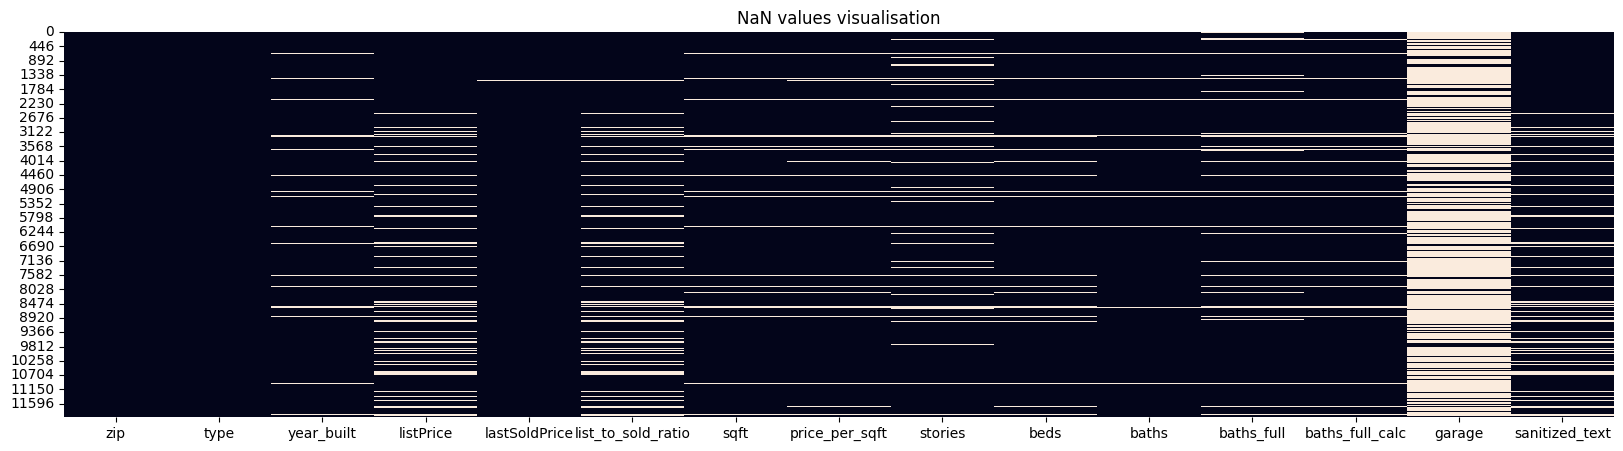

In [10]:
missing_val_overview(df)

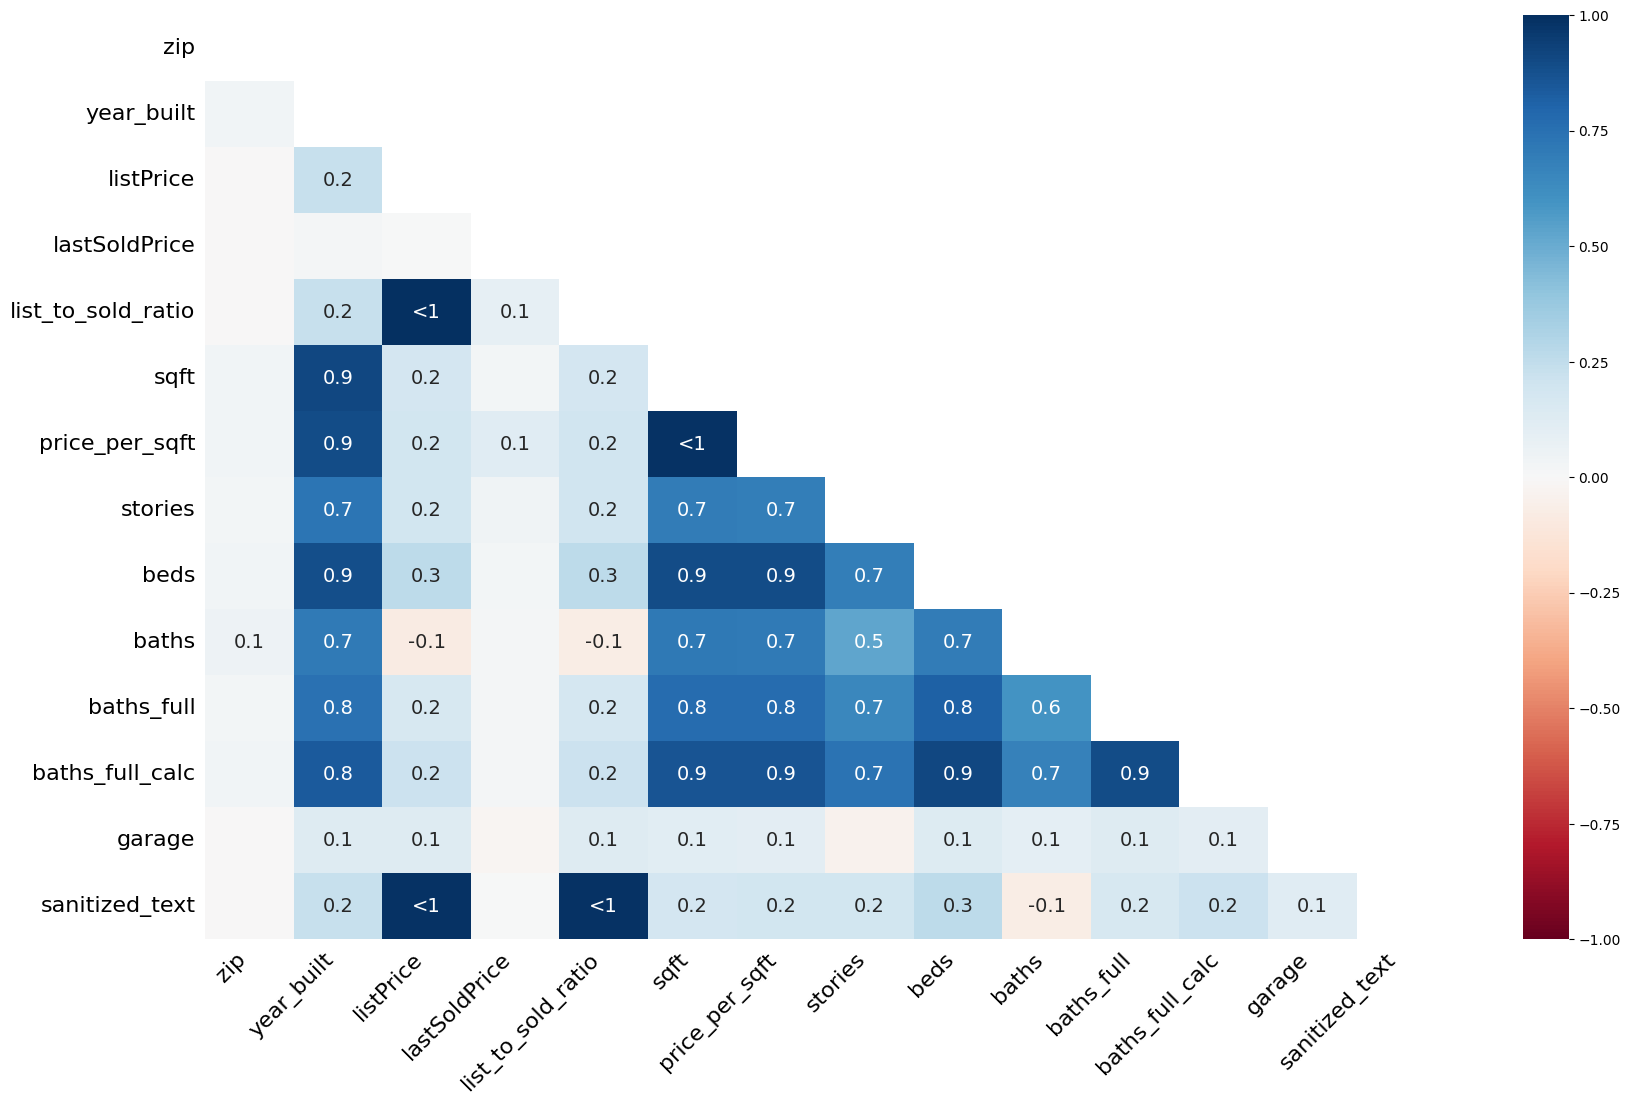

In [11]:
msno.heatmap(df)
plt.show()

### 4.c Remplacement des erreurs d'incrémentations du jeu de données
Voir dans 'Missing_values.ipynb' pour comprendre les choix

In [12]:
col_to_fill = ['stories', 'beds', 'garage', 'baths', 'baths_full', 'baths_full_calc']
df.loc[(df['type'] == 'land'), col_to_fill] = df.loc[(df['type'] == 'land'), col_to_fill].fillna(0)

### 4.d Suppression des 'spoil'
C'est variables sont calculé via le target. Nous les supprimons.

In [13]:
df = df.drop(columns=['list_to_sold_ratio', 'price_per_sqft'])

# 5. Ajout de variables de localisation

### 5.a Variable peuplement des villes

In [14]:
loc_data = pd.read_csv('uszips.csv')

In [15]:
loc_data.head(2)

,zip,lat,lng,city,state_id,state_name,zcta,parent_zcta,population,density,county_fips,county_name,county_weights,county_names_all,county_fips_all,imprecise,military,timezone
0,601,18.18027,-66.75266,Adjuntas,PR,Puerto Rico,True,NaN,16669.0,99.9,72001,Adjuntas,"{""72001"": 98.74, ""72141"": 1.26}",Adjuntas|Utuado,72001|72141,False,False,America/Puerto_Rico
1,602,18.36075,-67.17541,Aguada,PR,Puerto Rico,True,NaN,37233.0,474.0,72003,Aguada,"{""72003"": 100}",Aguada,72003,False,False,America/Puerto_Rico


In [16]:
# NaN for Whashington state
loc_data.loc[loc_data['population'].isna() & loc_data['state_name'] == 'Washington', ['zip', 'state_name', 'city', 'population',]]

C:\Users\Flo pro\AppData\Local\Temp\ipykernel_9856\1680428720.py:2: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  loc_data.loc[loc_data['population'].isna() & loc_data['state_name'] == 'Washington', ['zip', 'state_name', 'city', 'population',]]


,zip,state_name,city,population


In [17]:
# On garde le code zip et la taille de la population des villes
loc_data = loc_data[['zip', 'population']]

In [18]:
# Fusion des deux jeu de données
df = pd.merge(df, loc_data, on='zip', how='left')

### 5.b Variables zone géographique

In [19]:
def cat_zip(row):
    zip_code = str(row['zip'])
    #
    #  Mégalopole urbaine et technologique
    if zip_code.startswith(('980', '981', '982')):
        return 'puget_sound_core'
    # Zones portuaires, capitale d'état, et côte Pacifique
    elif zip_code.startswith(('983', '985', '986')):
        return 'south_and_coast'
    # Vallées agricoles et viticoles
    elif zip_code.startswith(('988', '989')):
        return 'central_valleys'
    # Seconde métropole de l'état
    elif zip_code.startswith(('990', '992', '993')):
        return 'spokane_inland_empire'
    # Autres zones peu peuplées
    elif zip_code.startswith(('98', '99')) :
        return 'other'

In [20]:
df['group_zip'] = df.apply(cat_zip, axis=1)

# 6. Visualisation univariée

### 6.a Variables numériques

In [21]:
num_col = list(df.select_dtypes(include=['int', 'float']).columns.drop('lastSoldPrice'))

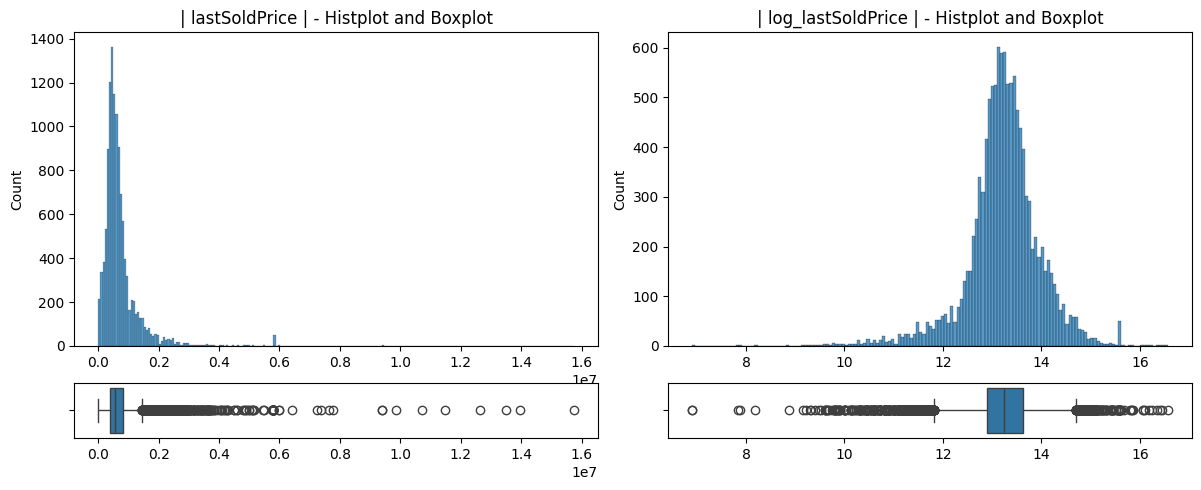

In [22]:
df_log = pd.DataFrame()
df_log['lastSoldPrice'] = df['lastSoldPrice']
df_log['log_lastSoldPrice'] = np.log1p(df['lastSoldPrice'])

proportion_visualisation(df_log, ['lastSoldPrice', 'log_lastSoldPrice'])  

In [23]:
print(f"lastSoldPrice minimum : {df['lastSoldPrice'].min()}")
print(f"lastSoldPrice maximum : {df['lastSoldPrice'].max()}")

lastSoldPrice minimum : 1000.0
lastSoldPrice maximum : 15751208.0


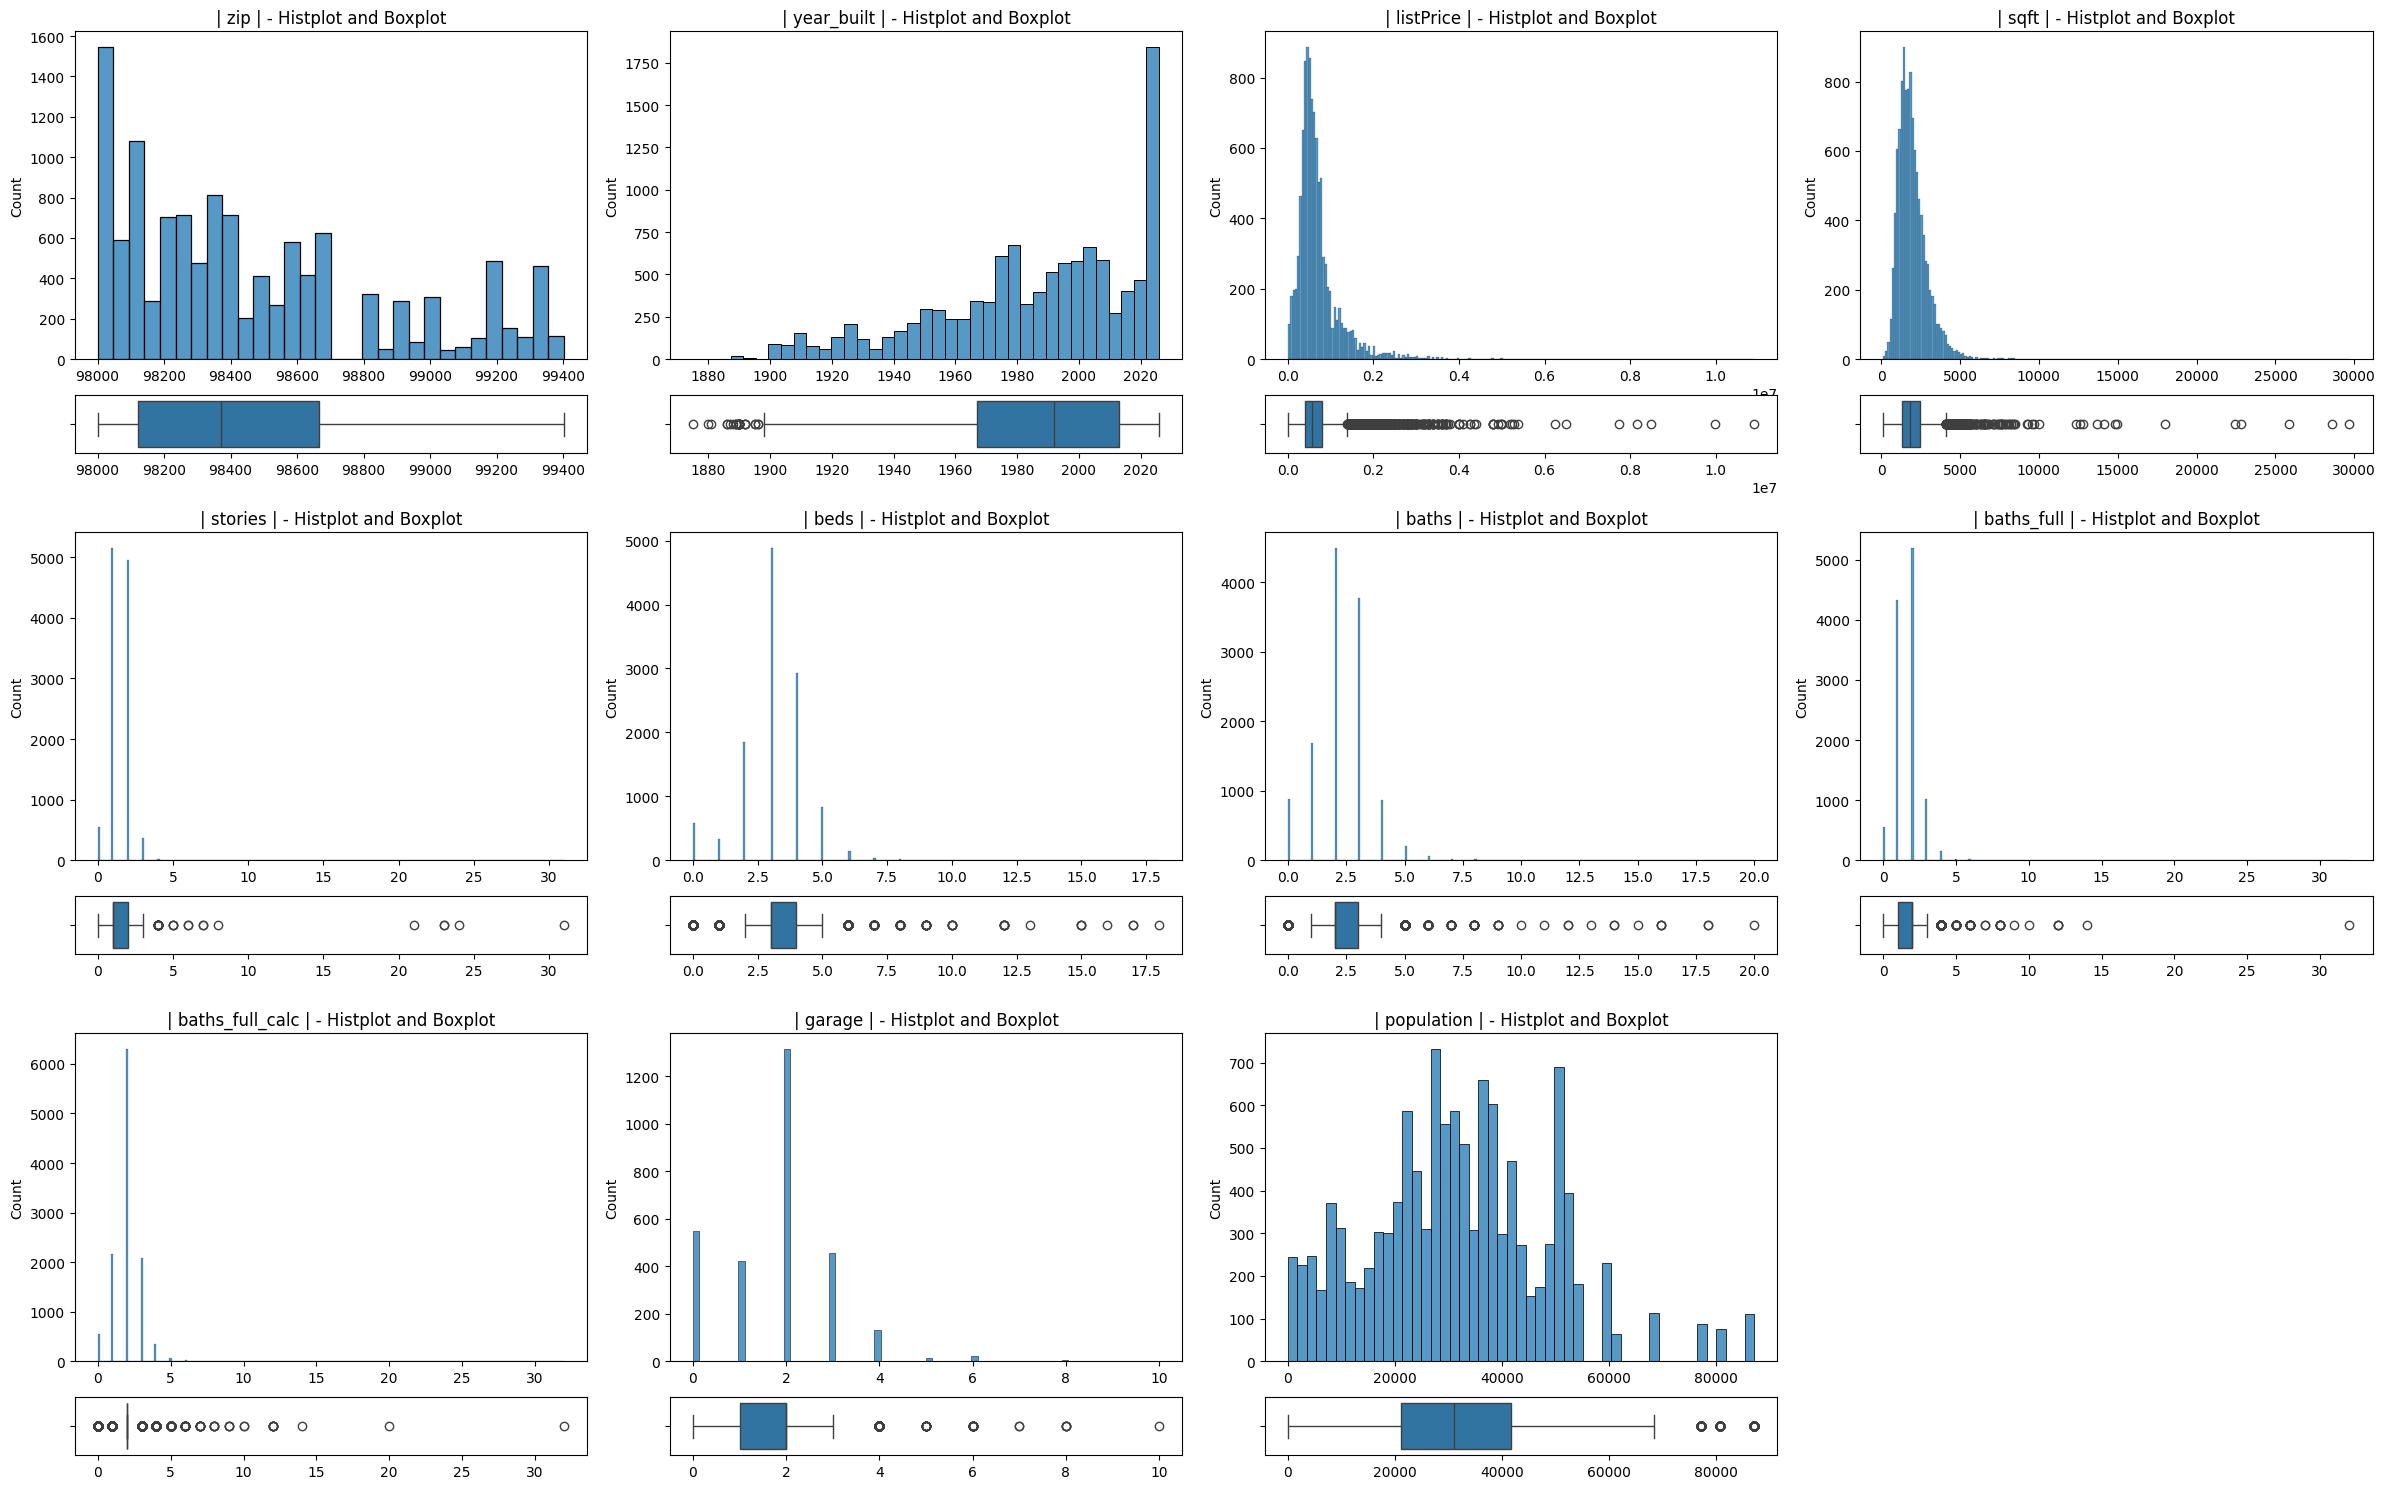

In [24]:
proportion_visualisation(df, num_col)

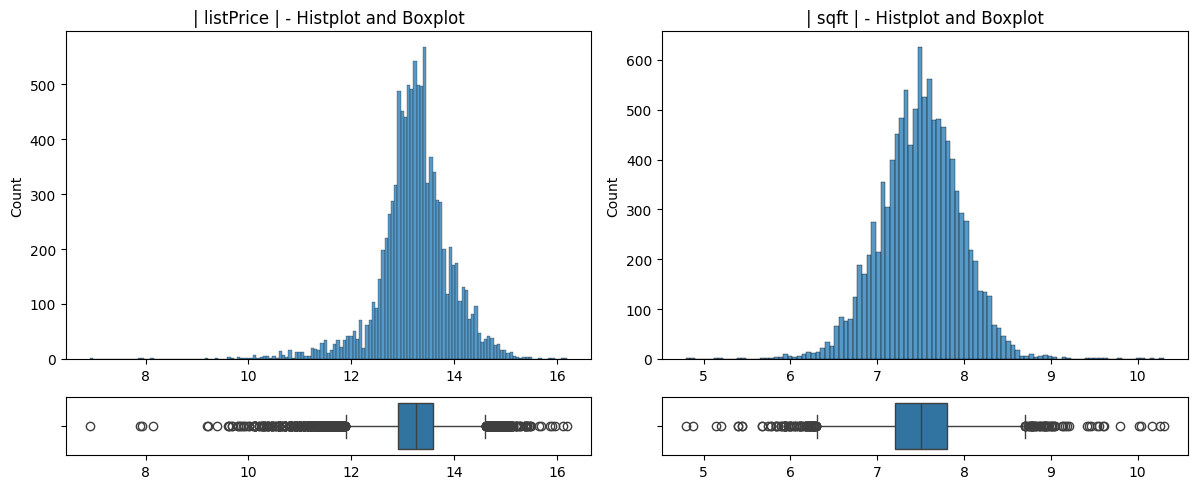

In [25]:
df_log = pd.DataFrame()
df_log[['listPrice', 'sqft']] = np.log1p(df[['listPrice', 'sqft']])

proportion_visualisation(df_log, ['listPrice', 'sqft'])

### 6.b Variables - salle de bain
D'après les normes américaines, "baths" devrait toujours être supérieur ou égal à "baths_full" (baths = full bath + three-quarter bath + half bath + quarter bath).    
Plusieurs propriétés ont des valeurs érronées.    
On peut voir que cette erreur est encore plus présente dans la version calculé (baths_full_calc).

In [26]:
(df['baths'] - df['baths_full']).value_counts().sort_index()

-3.0        2
-2.0        1
-1.0       37
 0.0     5429
 1.0     4297
 2.0     1314
 3.0      199
 4.0       19
 5.0        8
 6.0        4
 8.0        3
 9.0        1
 10.0       1
 11.0       1
Name: count, dtype: int64

In [27]:
(df['baths'] - df['baths_full_calc']).value_counts().sort_index()

-3.0        3
-2.0        3
-1.0       61
 0.0     7801
 1.0     3540
 2.0      130
 3.0        7
 4.0        3
 6.0        2
 8.0        1
 11.0       1
Name: count, dtype: int64

In [28]:
(df['baths_full'] - df['baths_full_calc']).value_counts().sort_index()

-8.0       1
-4.0       8
-3.0      38
-2.0     463
-1.0    2858
 0.0    7949
Name: count, dtype: int64

### 6.c Variables catégorielles

In [29]:
df['type'].value_counts()

type
single_family    8840
condo            1101
mobile            630
townhomes         574
land              549
multi_family      197
other             111
farm               10
coop                5
Name: count, dtype: int64

In [30]:
df['group_zip'].value_counts()

group_zip
puget_sound_core         5165
south_and_coast          3710
spokane_inland_empire    1621
other                     772
central_valleys           746
Name: count, dtype: int64

### 6.d Variable "sanitized_text"

In [31]:
print('"sanitized_text" :')
print(f'Nombre de doublons : {df["sanitized_text"].duplicated().sum()}')
print(f'Ratio : {round(df["sanitized_text"].duplicated().sum() / len(df) * 100, 2)} %')

"sanitized_text" :
Nombre de doublons : 1883
Ratio : 15.67 %


In [32]:
print(df['sanitized_text'].value_counts().max())

8


In [33]:
# Valeur la plus fréquente
dupl_max = df['sanitized_text'].value_counts().index[0]
# Prendre les lignes avec cette valeur
df_dupl = df[df['sanitized_text'] == dupl_max]
#
print(dupl_max)
display(df_dupl)

the foyer is open to spacious great room with vaulted ceiling. kitchen includes stainless steel appliances, quality cabinets with soft close doors and drawers.


,zip,type,year_built,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
443,98930.0,single_family,2025.0,401776.0,401932.0,1530.0,1.0,3.0,1.0,1.0,1.0,2.0,the foyer is open to spacious great room with ...,15730.0,central_valleys
557,98930.0,single_family,2026.0,413536.0,413548.0,1870.0,1.0,4.0,2.0,1.0,2.0,3.0,the foyer is open to spacious great room with ...,15730.0,central_valleys
3103,99301.0,single_family,2026.0,455587.0,455432.0,1600.0,1.0,3.0,2.0,1.0,2.0,2.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire
4001,99301.0,single_family,2026.0,490218.0,490391.0,1590.0,1.0,3.0,2.0,1.0,2.0,3.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire
5366,99301.0,single_family,2026.0,374181.0,374160.0,1150.0,1.0,1.0,2.0,2.0,2.0,2.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire
5670,98930.0,single_family,2025.0,389782.0,389919.0,1590.0,1.0,3.0,1.0,1.0,1.0,2.0,the foyer is open to spacious great room with ...,15730.0,central_valleys
8373,99301.0,single_family,2025.0,588741.0,558718.0,1670.0,1.0,3.0,2.0,2.0,2.0,3.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire
10704,99301.0,single_family,2025.0,484257.0,484259.0,1870.0,1.0,4.0,2.0,1.0,2.0,3.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire


In [34]:
# Valeur la plus fréquente
dupl_max = df['sanitized_text'].value_counts().index[20]
# Prendre les lignes avec cette valeur
df_dupl = df[df['sanitized_text'] == dupl_max]
#
print(dupl_max)
display(df_dupl)

the Bennett at Ivy Terrace is designed for modern living. the open main floor invites you in with a bright kitchen, dining, and living space ideal for hosting, relaxing, and everyday life.


,zip,type,year_built,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
3168,98087.0,townhomes,2026.0,615086.0,615066.0,1440.0,2.0,2.0,3.0,1.0,2.0,NaN,the Bennett at Ivy Terrace is designed for mod...,41796.0,puget_sound_core
3542,98087.0,townhomes,2026.0,614941.0,615063.0,1440.0,2.0,2.0,3.0,1.0,2.0,NaN,the Bennett at Ivy Terrace is designed for mod...,41796.0,puget_sound_core
8642,98087.0,townhomes,2026.0,615091.0,615067.0,1440.0,2.0,2.0,3.0,1.0,2.0,NaN,the Bennett at Ivy Terrace is designed for mod...,41796.0,puget_sound_core


In [35]:
df['Length_text'] = df['sanitized_text'].str.len()

In [36]:
def word_count(review):
    if isinstance(review, str):
        return len(review.split())
    return np.nan

df['Word_count_text'] = df['sanitized_text'].apply(word_count)

In [37]:
df['mean_word_length_text'] = df['sanitized_text'].map(
    lambda rev: np.mean([len(word) for word in rev.split()]) if isinstance(rev, str) else np.nan
)

In [38]:
df['mean_sent_length_text'] = df['sanitized_text'].map(
    lambda rev: np.mean([len(sent) for sent in tokenize.sent_tokenize(rev)]) if isinstance(rev, str) else np.nan
    )

In [39]:
text_col = ['Length_text', 'Word_count_text', 'mean_word_length_text', 'mean_sent_length_text']

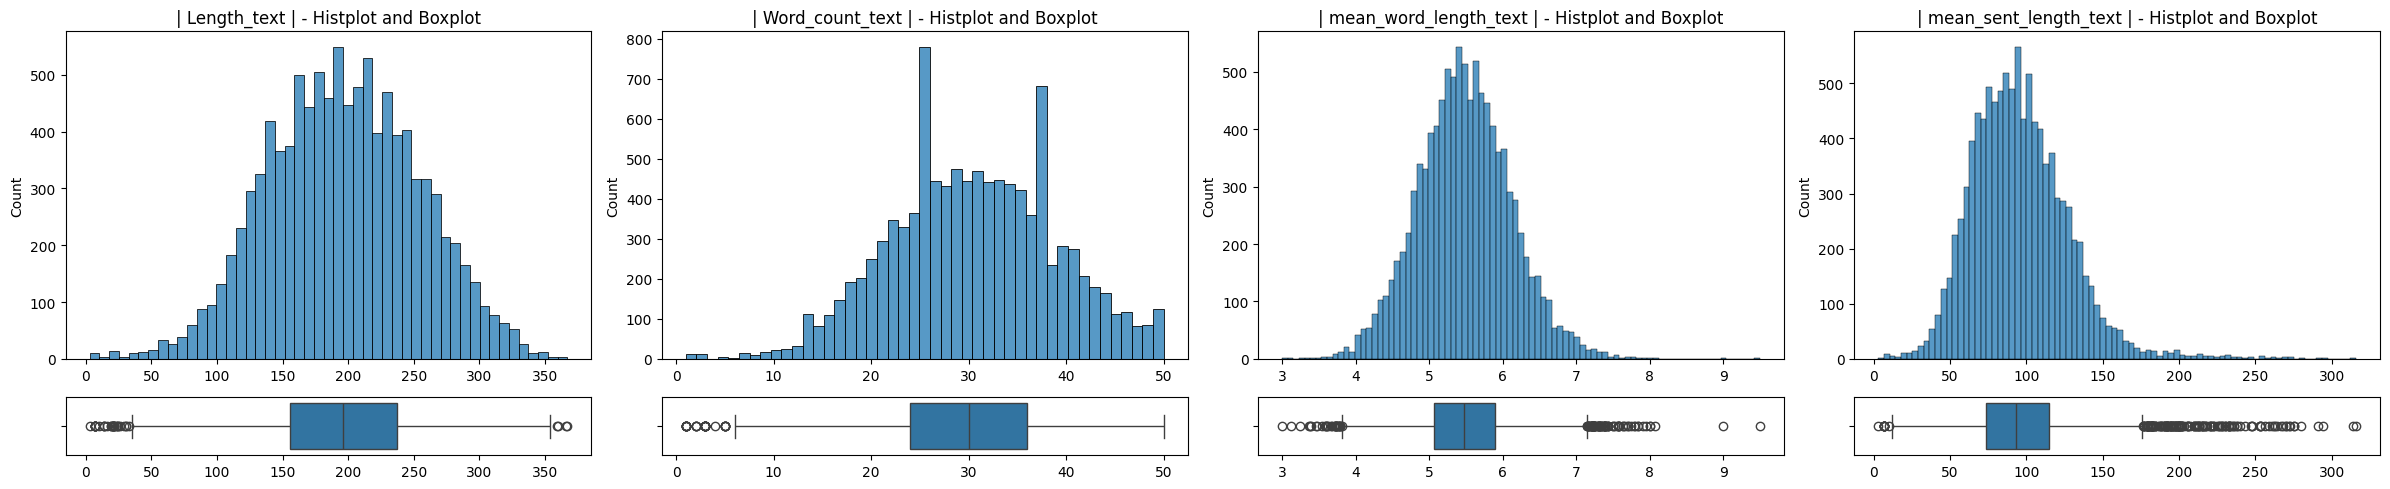

In [40]:
proportion_visualisation(df, text_col)

# 8. Valeurs manquantes

### 8.a Analyse des variables
Voir le fichier 'Missing_values.ipynb'

### 8.b Proportion des NaN
Beaucoup de lignes avec une majorité de NaN.  
On pourrait se poser la question si on doit les garder ou mettre un seuil limite.

In [41]:
# Compter le nombre de NaN par ligne
nan_counts = df.isna().sum(axis=1)

# Compter la fréquence de chaque nombre de NaN (de 0 à 15)
# value_counts() retourne seulement les valeurs présentes, on réindexe pour avoir tout de 0 à 15
distrib_nan = nan_counts.value_counts().sort_index()

print(distrib_nan)

0     1847
1     7474
2      835
3       66
4       59
5       23
6      116
7     1034
8      152
9       74
10      44
11      33
12      17
13     242
14       1
Name: count, dtype: int64


# 9. Variables / target

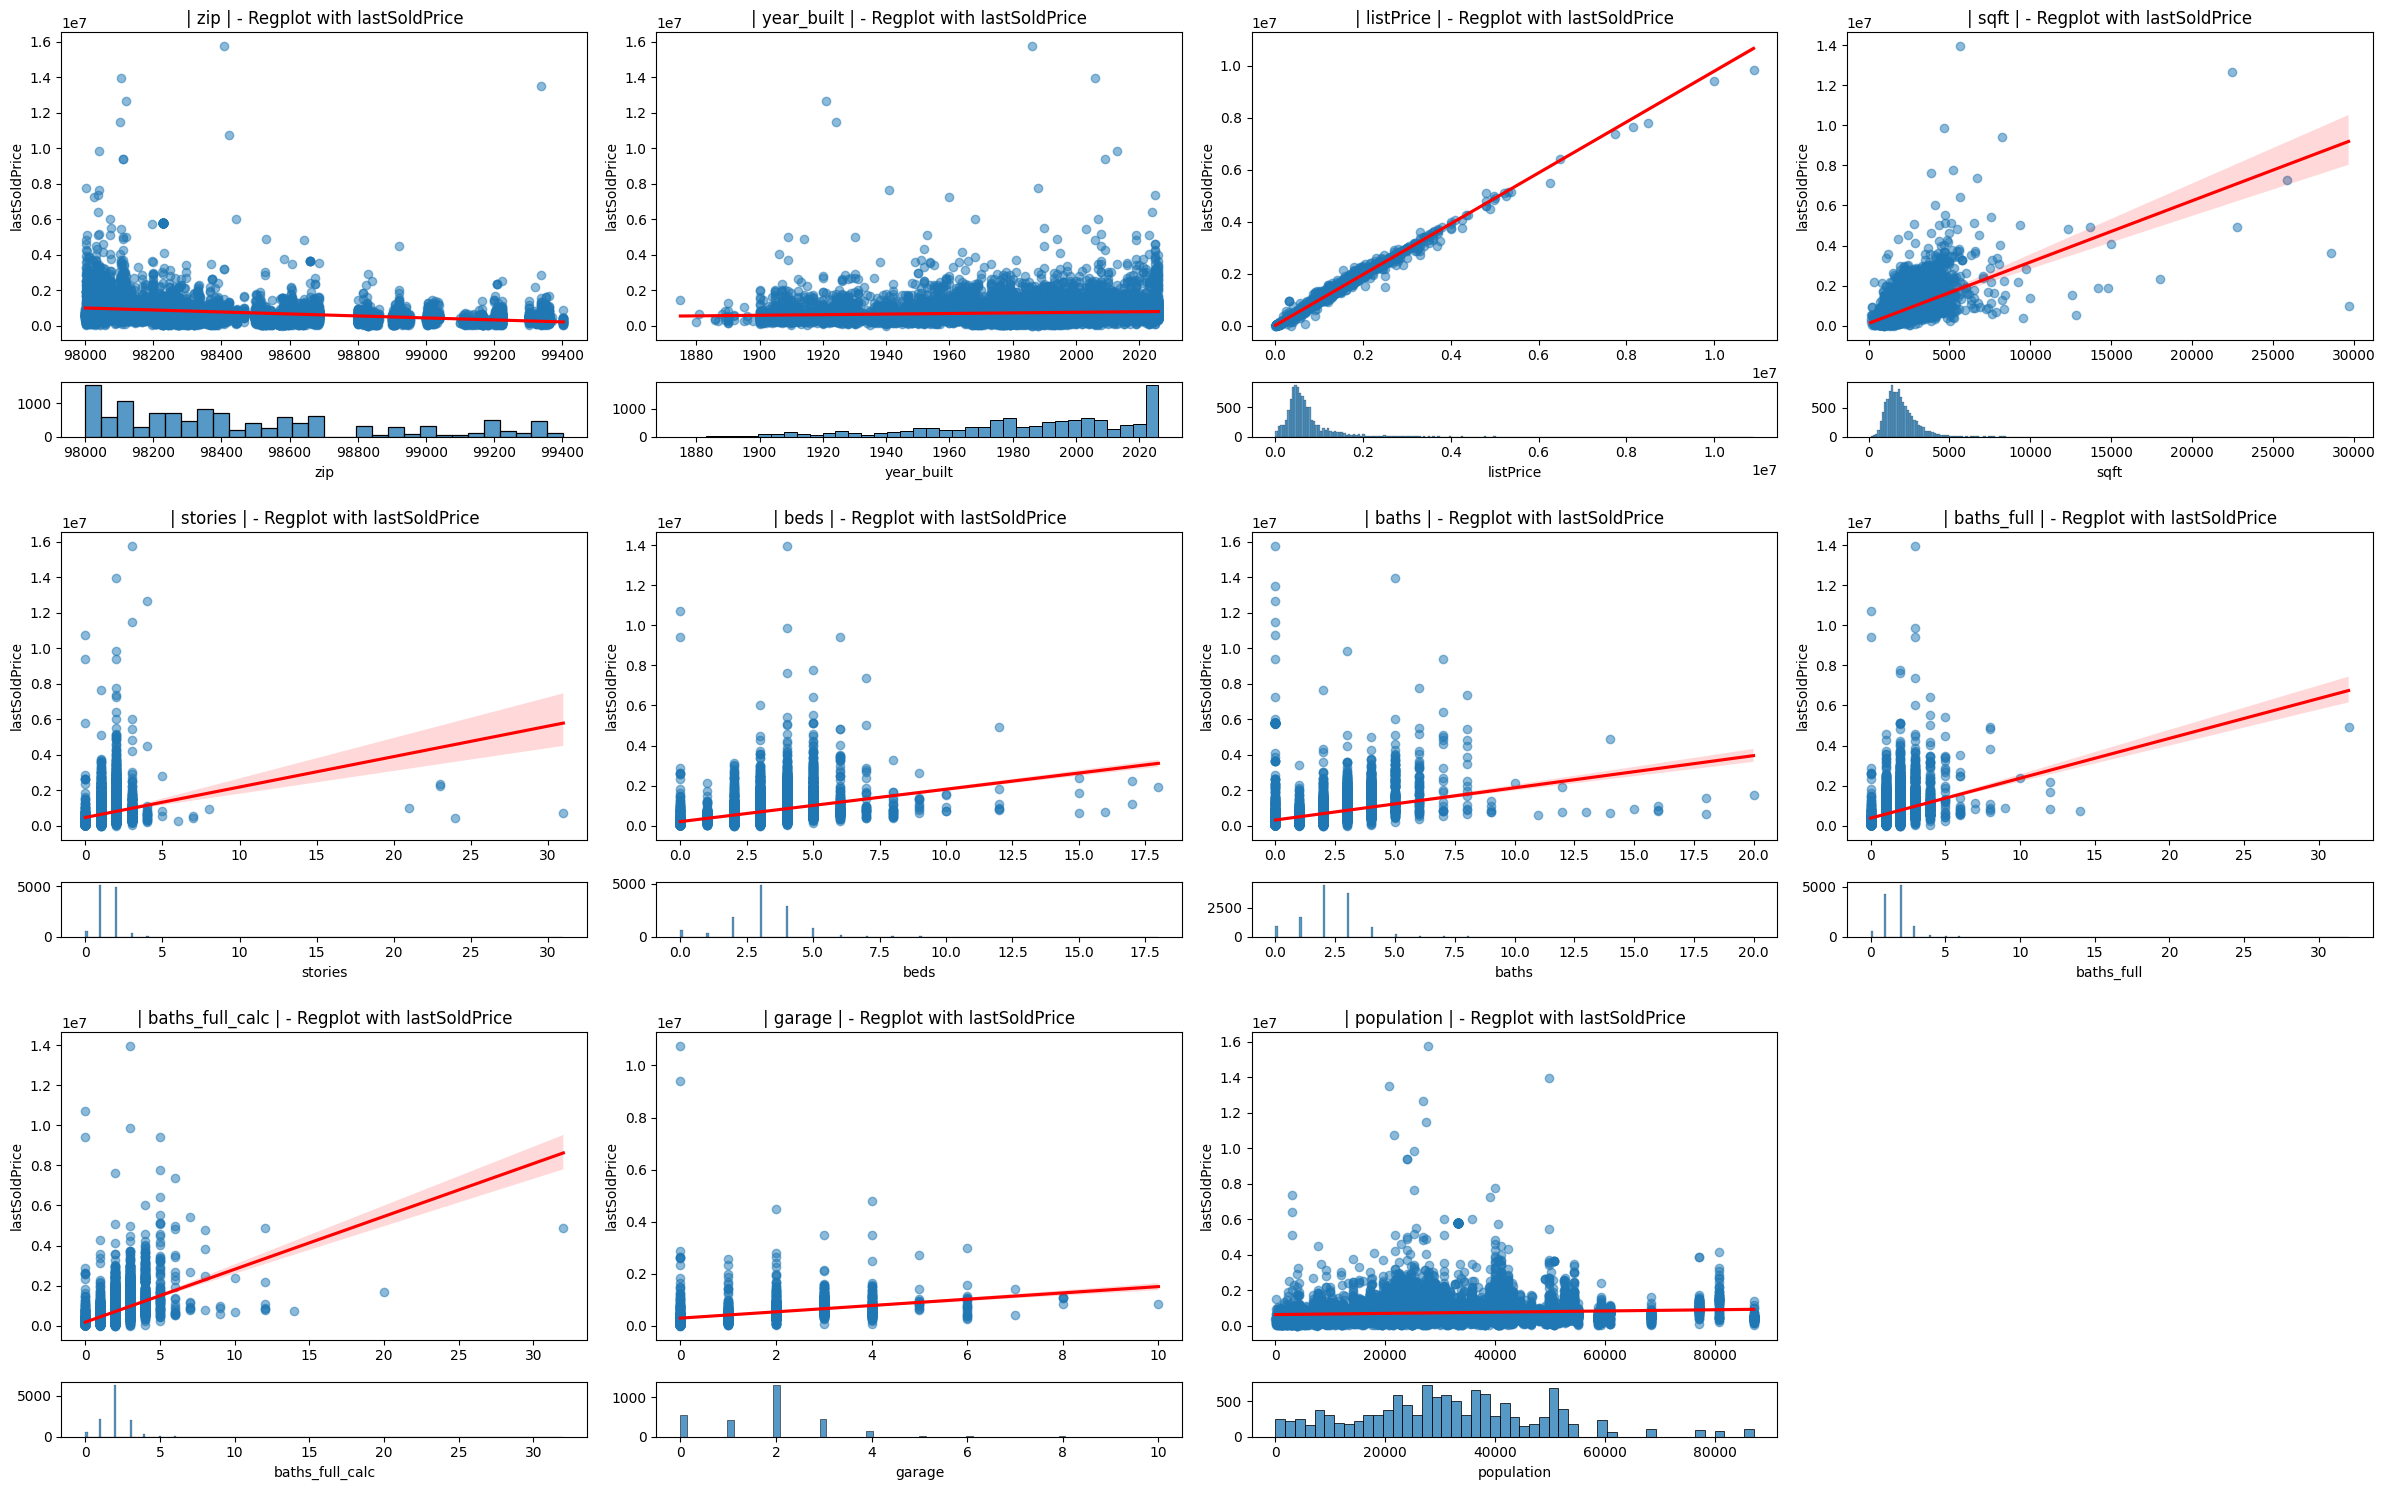

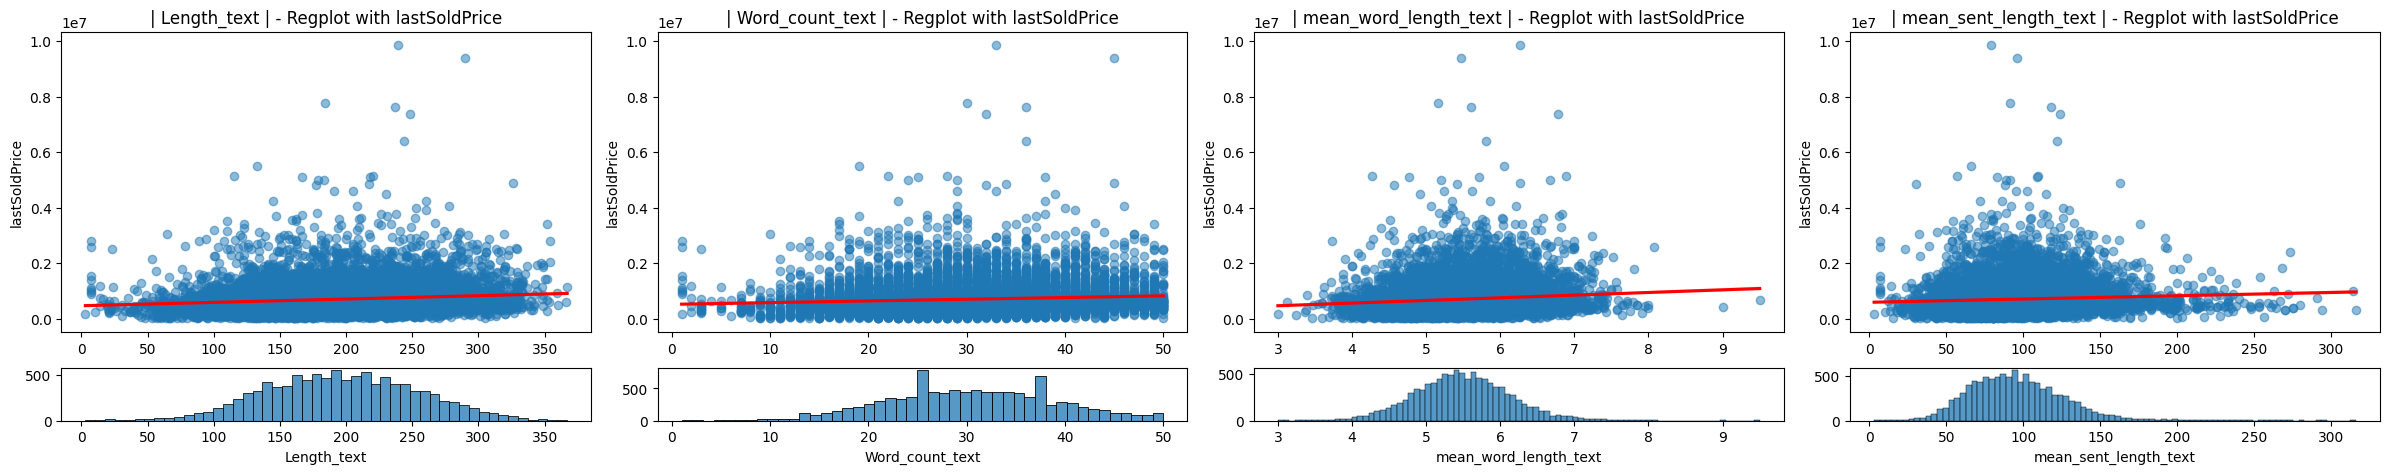

In [42]:
regplot_visualisation(df, num_col, 'lastSoldPrice')
regplot_visualisation(df, text_col, 'lastSoldPrice')

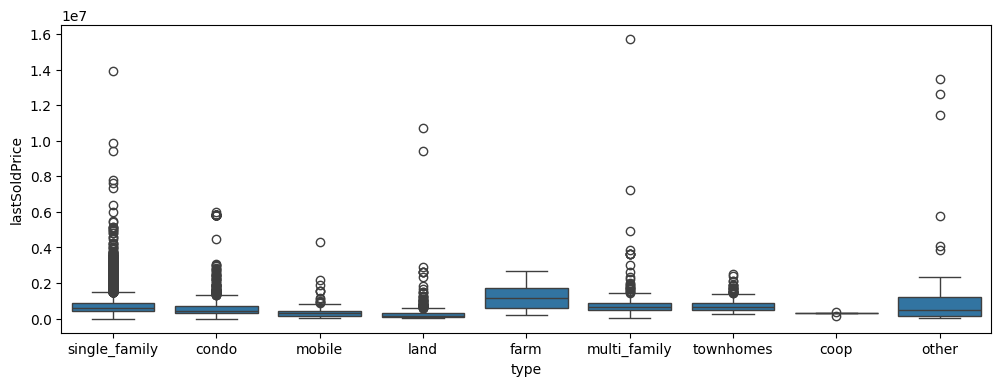

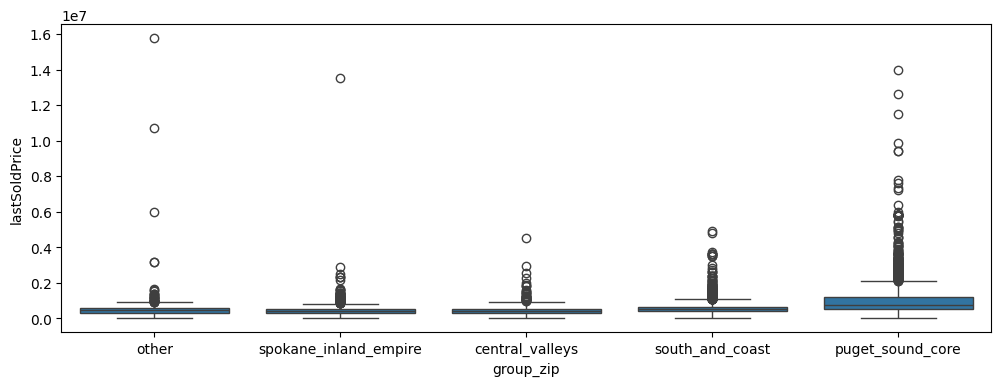

In [43]:
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='lastSoldPrice')
plt.show()

plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='group_zip', y='lastSoldPrice')
plt.show()

### 9.b Log de target

In [44]:
df_log = pd.DataFrame()
df_log = df.copy()
df_log[['lastSoldPrice', 'listPrice', 'sqft']] = np.log1p(df[['lastSoldPrice', 'listPrice', 'sqft']])

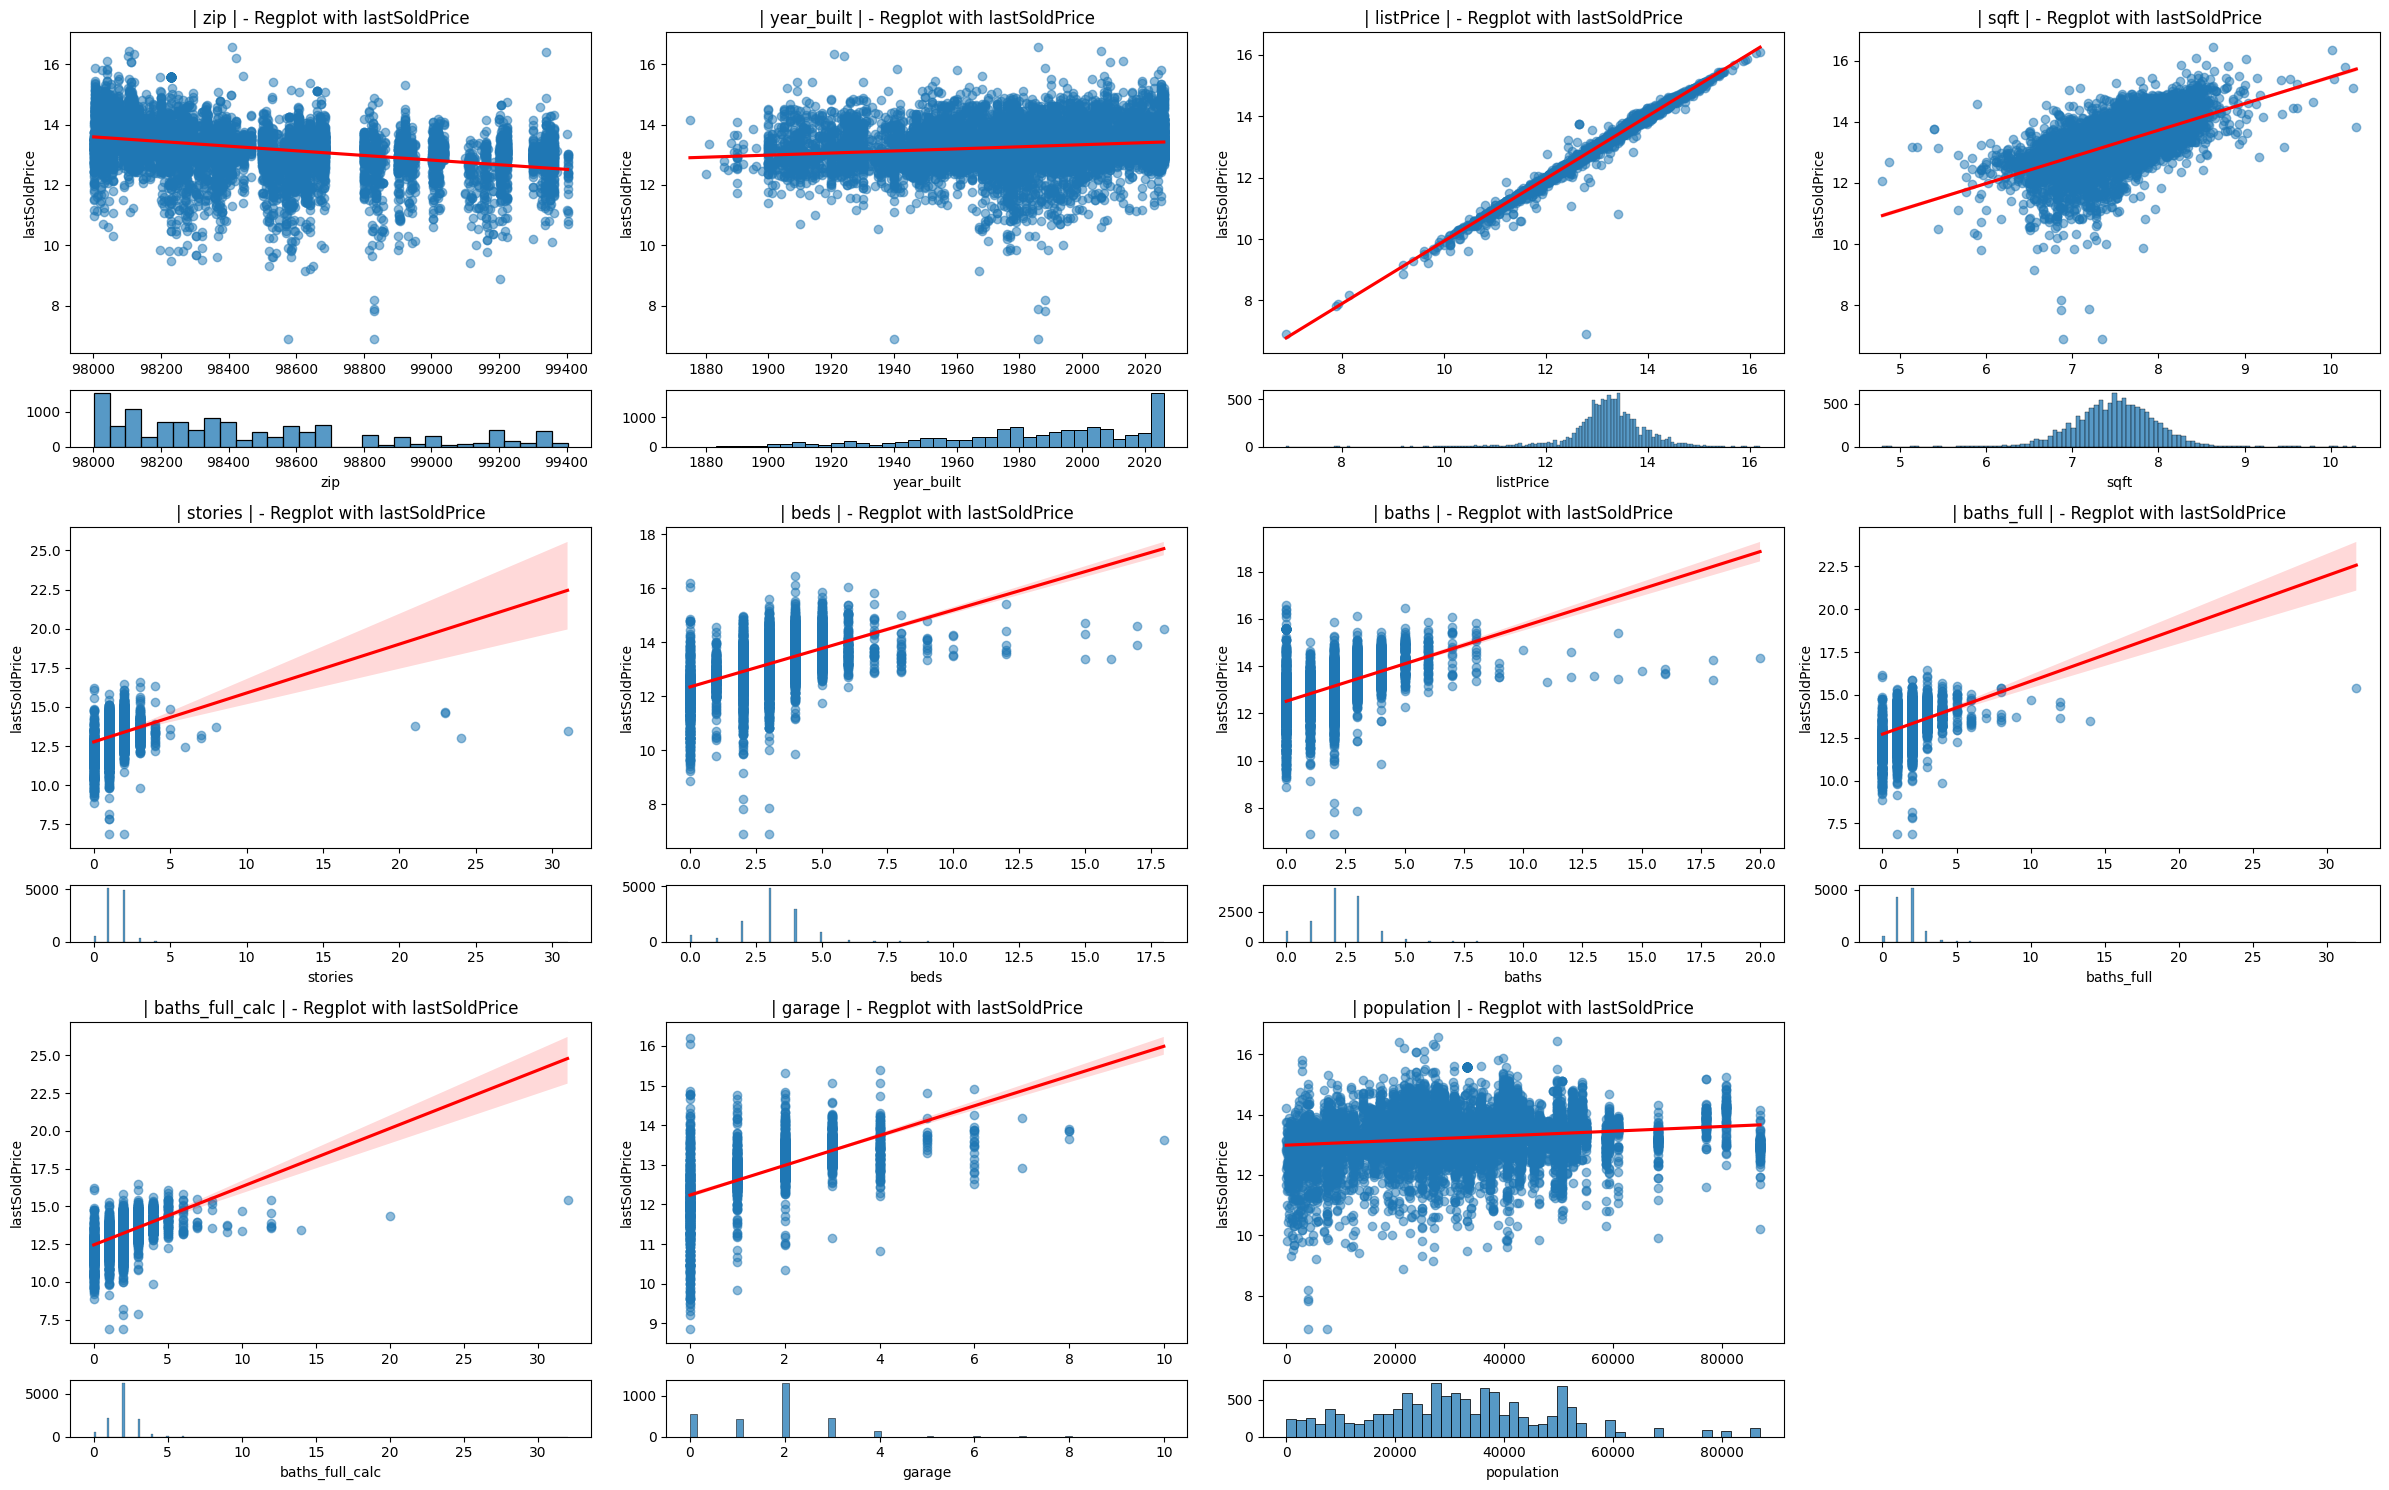

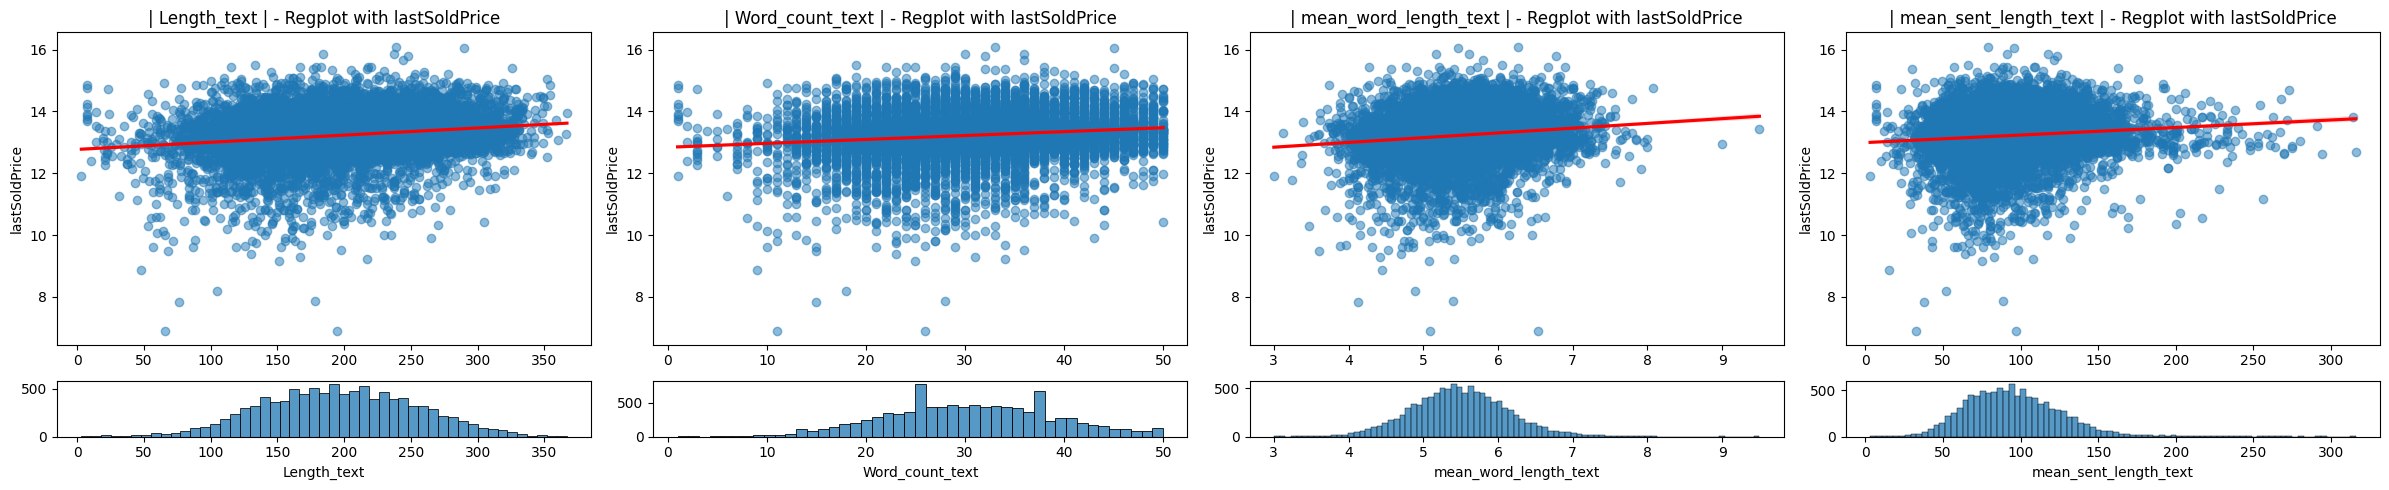

In [45]:
regplot_visualisation(df_log, num_col, 'lastSoldPrice')
regplot_visualisation(df_log, text_col, 'lastSoldPrice')

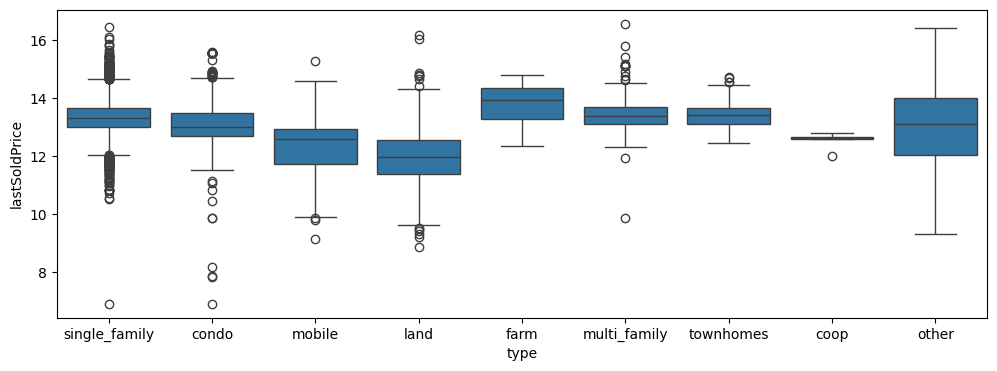

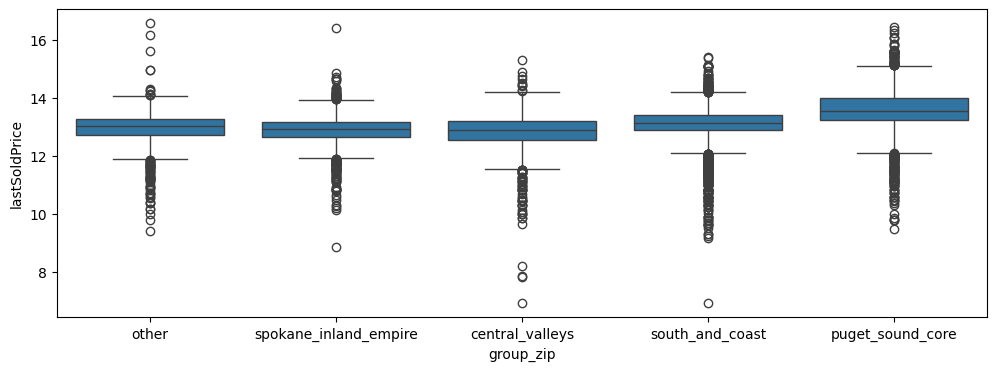

In [46]:
plt.figure(figsize=(12,4))
sns.boxplot(data=df_log, x='type', y='lastSoldPrice')
plt.show()

plt.figure(figsize=(12,4))
sns.boxplot(data=df_log, x='group_zip', y='lastSoldPrice')
plt.show()

# 10. Pairplot

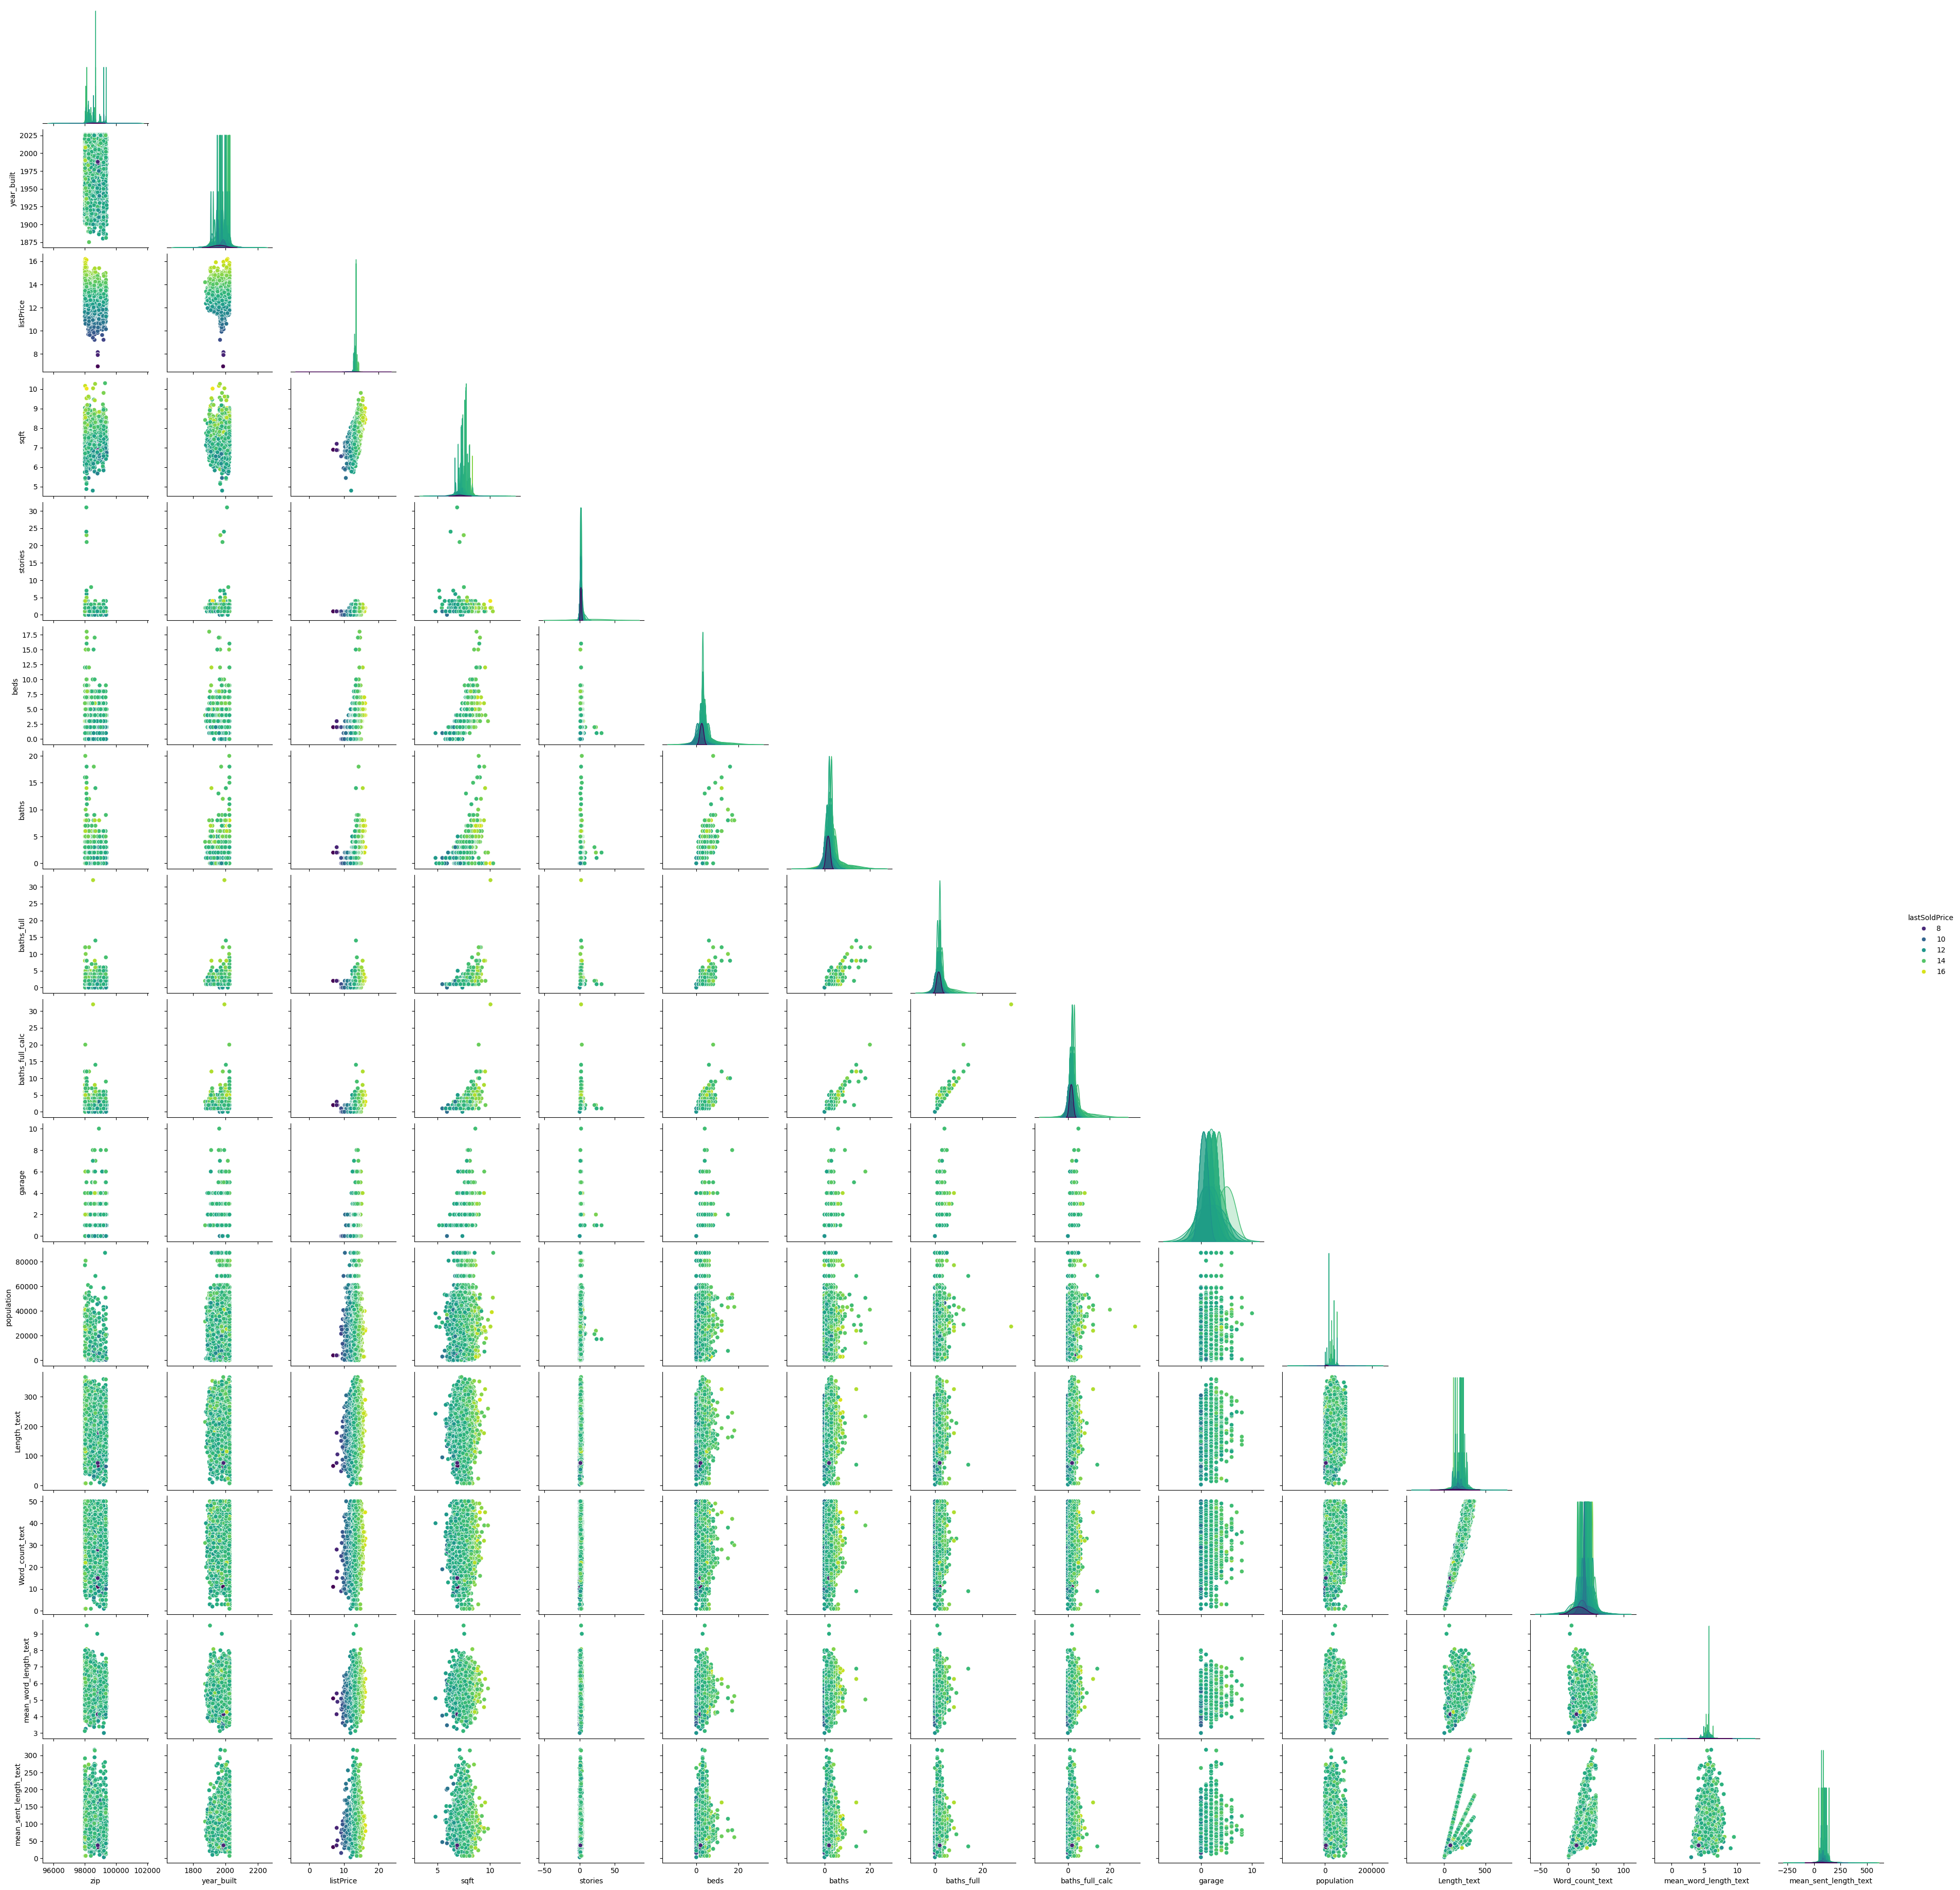

In [47]:
sns.pairplot(df_log, hue='lastSoldPrice', palette='viridis', corner=True)
plt.show()

# 11. Matrice de corrélation

In [48]:
def corr_matrix(df, col, corr_method):
    # Compute the correlation matrix
    corr = df[col].corr(method=corr_method)

    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Correlation graph
    plt.figure(figsize=(12, 6))

    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, cbar=False)
    plt.title(f'{corr_method} correlation')

    plt.show()

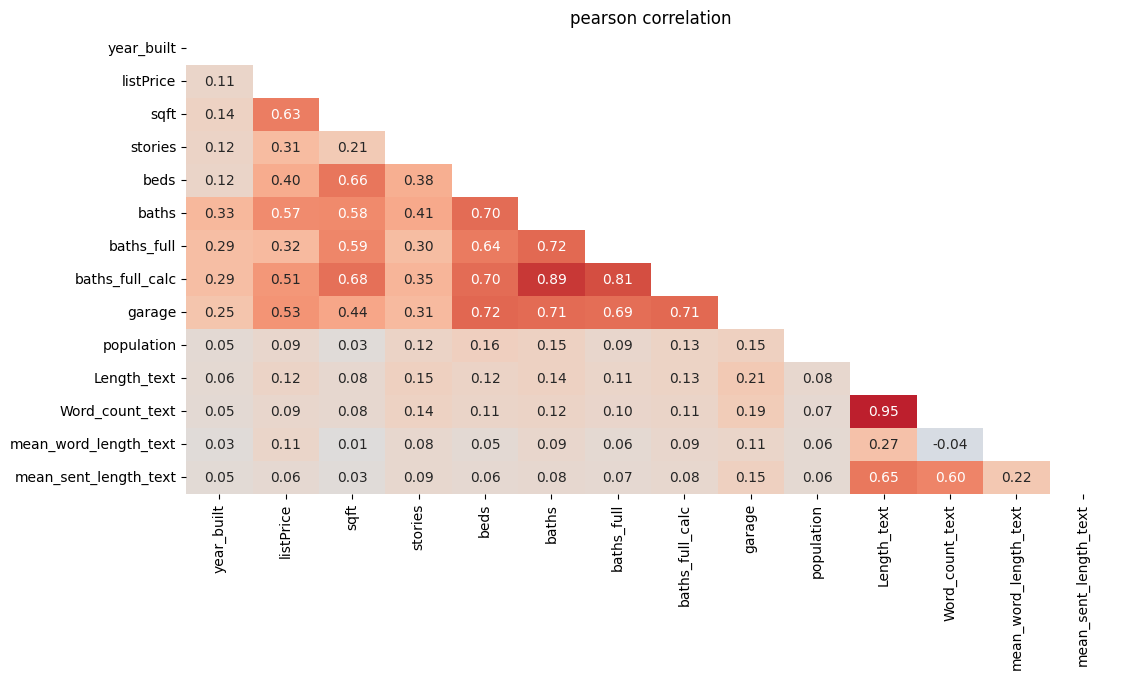

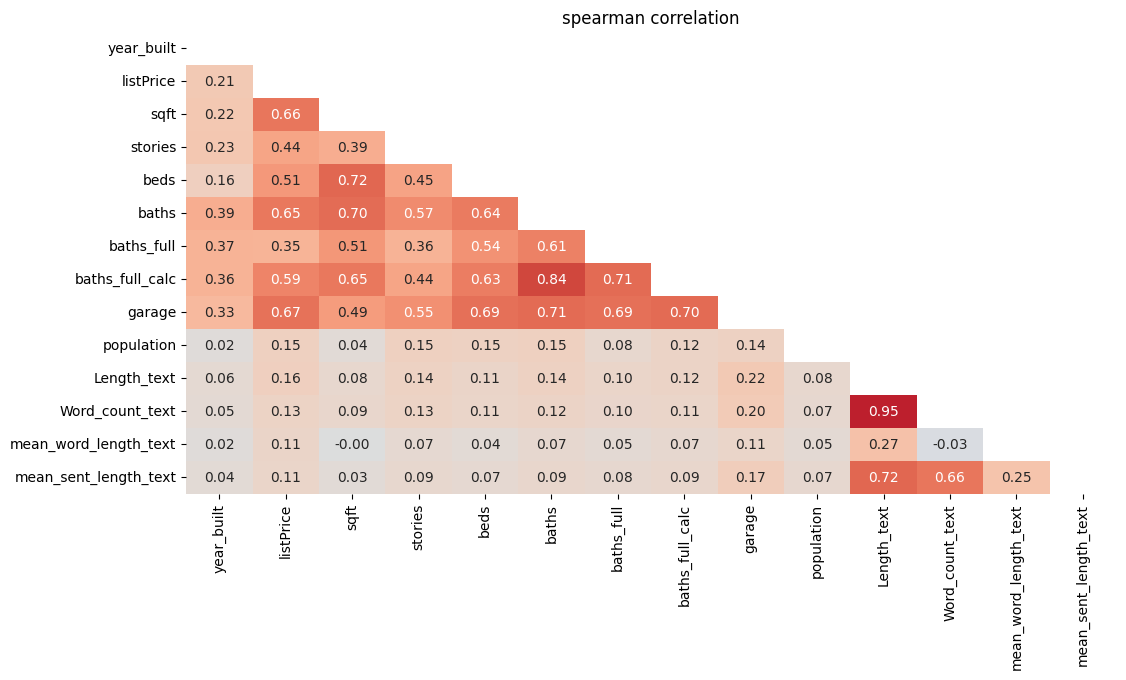

In [49]:
corr_col = df.select_dtypes(['int', 'float']).columns.drop(['zip', 'lastSoldPrice'])

corr_matrix(df, corr_col, 'pearson')
corr_matrix(df, corr_col, 'spearman')

# 12. Modèle de test

In [104]:
df = data_raw.copy()

In [105]:
df = df.dropna(subset=['lastSoldPrice'])

### 12.a Suppression colonnes qui "spoil" + doublon "bath"

In [106]:
df = df.drop(columns=['list_to_sold_ratio', 'price_per_sqft', 'baths_full', 'baths_full_calc'])

### 12.b Remplissage NaN

In [107]:
def FillIncrementationError(data, to_fill_col):
    mask_land = data['type'] == 'land'
    #
    for col in to_fill_col:
        data.loc[mask_land, col] = data.loc[mask_land, col].fillna(0)

    return data

In [108]:
from sklearn.impute import SimpleImputer

In [109]:
fill_error_col = ['stories', 'beds', 'garage', 'baths']
fill_median_col = ['year_built', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'garage']
fill_mode_col = ['zip']

df = FillIncrementationError(df, fill_error_col)

imputer_median = SimpleImputer(strategy='median')
df[fill_median_col] = imputer_median.fit_transform(df[fill_median_col])

imputer_mode = SimpleImputer(strategy='most_frequent')
df[fill_mode_col] = imputer_mode.fit_transform(df[fill_mode_col])

### 12.c Ajout localisation

In [110]:
loc_data = pd.read_csv('uszips.csv')
#
loc_data = loc_data[['zip', 'population']]

df = pd.merge(df, loc_data, on='zip', how='left')

In [111]:
# 98206 --> Everett, WA = 114 000 pop
mask = df['zip'] == 98206.0
df.loc[mask, 'population'] = df.loc[mask, 'population'].fillna(114000.0)

In [112]:
def cat_zip(row):
    zip_code = str(row['zip'])
    #
    #  Mégalopole urbaine et technologique
    if zip_code.startswith(('980', '981', '982')):
        return 'puget_sound_core'
    # Zones portuaires, capitale d'état, et côte Pacifique
    elif zip_code.startswith(('983', '985', '986')):
        return 'south_and_coast'
    # Vallées agricoles et viticoles
    elif zip_code.startswith(('988', '989')):
        return 'central_valleys'
    # Seconde métropole de l'état
    elif zip_code.startswith(('990', '992', '993')):
        return 'spokane_inland_empire'
    # Autres zones peu peuplées
    elif zip_code.startswith(('98', '99')) :
        return 'other'

In [113]:
df['group_zip'] = df.apply(cat_zip, axis=1)

### 12.d Ajout données de texte

In [114]:
def word_count(review):
    if isinstance(review, str):
        return len(review.split())
    return 0 

In [115]:
df['length_text'] = df['sanitized_text'].str.len()
df['length_text'] = df['length_text'].fillna(0)

df['word_count_text'] = df['sanitized_text'].apply(word_count)

df['mean_word_length_text'] = df['sanitized_text'].map(
    lambda rev: np.mean([len(word) for word in rev.split()]) if isinstance(rev, str) else 0
)

df['mean_sent_length_text'] = df['sanitized_text'].map(
    lambda rev: np.mean([len(sent) for sent in tokenize.sent_tokenize(rev)]) if isinstance(rev, str) else 0
    )

### 12.e Suppression des colonnes inutiles pour le modèle

In [116]:
df = df.drop(columns=['sanitized_text', 'zip'])

### 12.f Standardisation des données

In [117]:
from sklearn.preprocessing import RobustScaler

scale_col = ['year_built', 'listPrice',  'sqft', 'stories', 'beds', 'baths', 'garage',
             'population', 'length_text', 'word_count_text', 'mean_word_length_text', 'mean_sent_length_text']

robust_scaler = RobustScaler()
df[scale_col] = robust_scaler.fit_transform(df[scale_col])

### 12.g Encodage des colonnes catégorielles

In [118]:
from sklearn.preprocessing import OneHotEncoder

one_hot_col = ['type', 'group_zip']

encoder_one_hot = OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.02, sparse_output=False)
encoded_data = encoder_one_hot.fit_transform(df[one_hot_col])
encoded_df = pd.DataFrame(encoded_data, columns=encoder_one_hot.get_feature_names_out(one_hot_col), index=df.index)
df = pd.concat([df, encoded_df], axis=1).drop(one_hot_col, axis=1)

### 12.h Evaluation des modèles

In [119]:
from sklearn.model_selection import train_test_split

target = 'lastSoldPrice'

X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [120]:
from sklearn.model_selection import learning_curve, cross_validate, KFold

In [121]:
def model_evaluation(X_train, y_train, pipe, cv):
    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'MedianAE': 'neg_median_absolute_error',
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2',
        },
        return_train_score=False,
        n_jobs=-1
    )

    return cv_scores

In [122]:
def model_learning_curve(X_train, y_train, pipe, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_median_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
    )

    return train_sizes, train_scores, val_scores


def learning_curve_plot(lc_data):
    n_models = len(lc_data)
    cols = 3
    rows = int(np.ceil(n_models / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for ax, data in zip(axes, lc_data):

        size = data['t_size']
        tscore = data['t_score']
        vscore = data['v_score']

        train_scores_mean = -tscore.mean(axis=1)
        val_scores_mean = -vscore.mean(axis=1)

        ax.plot(size, train_scores_mean, marker='o', label='Train MAE')
        ax.plot(size, val_scores_mean, marker='o', label='Validation MAE')

        ax.set_title(data['model'])
        ax.grid(True)

        ax.legend()

    plt.tight_layout()
    plt.show()

In [123]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [124]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)

In [125]:
models = {
    'Dummy regressor': DummyRegressor(strategy='mean'),
    'linear_regression': LinearRegression(),
    'random_forest': RandomForestRegressor(random_state=0),
}

Quand on connais le prix de la mise en vente

In [126]:
results = []

for model_name, model in models.items():
    cv_scores = model_evaluation(X_train, y_train, model, cv)

    results.append({
    'model': model_name,
    'MedianAE_mean': np.round(-cv_scores['test_MedianAE'].mean(), 2),
    'MAE_mean': np.round(-cv_scores['test_MAE'].mean(), 2),
    'RMSE_mean': np.round(-cv_scores['test_RMSE'].mean(), 2),
    'R2_mean': np.round(cv_scores['test_R2'].mean(), 2),
    })

results_df = pd.DataFrame(results).sort_values('MAE_mean').reset_index(drop=True)
print(results_df)

               model  MedianAE_mean   MAE_mean  RMSE_mean  R2_mean
0      random_forest       12230.45   74628.62  347892.60     0.75
1  linear_regression       85748.16  164597.10  469615.88     0.56
2    Dummy regressor      277364.80  389006.10  702031.38    -0.00


Quand on ne connais pas le prix souhaité

In [127]:
target = 'lastSoldPrice'

X = df.drop(columns=[target, 'listPrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [128]:
results = []

for model_name, model in models.items():
    cv_scores = model_evaluation(X_train, y_train, model, cv)

    results.append({
    'model': model_name,
    'MedianAE_mean': np.round(-cv_scores['test_MedianAE'].mean(), 2),
    'MAE_mean': np.round(-cv_scores['test_MAE'].mean(), 2),
    'RMSE_mean': np.round(-cv_scores['test_RMSE'].mean(), 2),
    'R2_mean': np.round(cv_scores['test_R2'].mean(), 2),
    })

results_df = pd.DataFrame(results).sort_values('MAE_mean').reset_index(drop=True)
print(results_df)

               model  MedianAE_mean   MAE_mean  RMSE_mean  R2_mean
0      random_forest       95776.29  197837.33  478624.38     0.53
1  linear_regression      162091.56  270056.37  569758.99     0.34
2    Dummy regressor      277364.80  389006.10  702031.38    -0.00


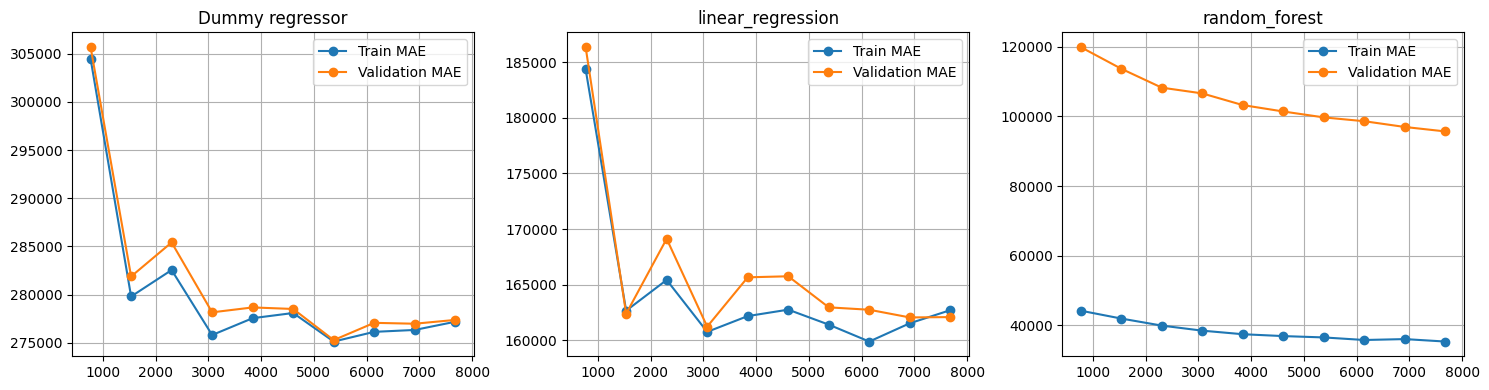

In [129]:
lc_data = []

for model_name, model in models.items():
    train_sizes, train_scores, val_scores = model_learning_curve(X_train, y_train, model, cv)

    lc_data.append({
        'model': model_name,
        't_size': train_sizes,
        't_score': train_scores,
        'v_score': val_scores
    })

learning_curve_plot(lc_data)